## Exercise: Comparison of RNN, LSTM, and GRU

1. Using the surface temperature (SST) time series  dataset and the same data preparation as in the previous section, train an LSTM and GRU with the same architecture and experimental configuration  and fill in the results table:

| Model | MAE | RMSE | MAPE (%) |
|-------|-----|------|----------|
| RNN   |     |      |          |
| LSTM  |     |      |          |
| GRU   |     |      |          |

Visualise the predictions of the three models in the same plot to facilitate comparison.

In [34]:
import numpy as np
import torch
import torch.nn as nn

import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt


In [35]:
df = pd.read_csv("SST_ABSO_002.00E_004.00E_38.00N_40.00N_19800101_20251231_timeseries.csv", header=2)
print(df.columns)
print(df.shape)

Index(['year', 'month', 'day', 'mean temperature kelvin',
       'mean temperature deg C', 'mean temperature uncertainty',
       'fraction of sea-ice-covered ocean'],
      dtype='str')
(3312, 7)


In [36]:
X_features = df[['year', 'month', 'day', 'mean temperature uncertainty']].values
X_target = df[['mean temperature deg C']].values

# Scalers independents
scaler_features = MinMaxScaler()
scaler_target   = MinMaxScaler()

features_scaled = scaler_features.fit_transform(X_features)
target_scaled   = scaler_target.fit_transform(X_target)

n_train = int(df.shape[0]*0.8)

features_train = features_scaled[:n_train,:]
features_test = features_scaled[n_train:,:]

target_train = target_scaled[:n_train,:]
target_test = target_scaled[n_train:,:]


print(features_train.shape)
print(target_test.shape)

(2649, 4)
(663, 1)


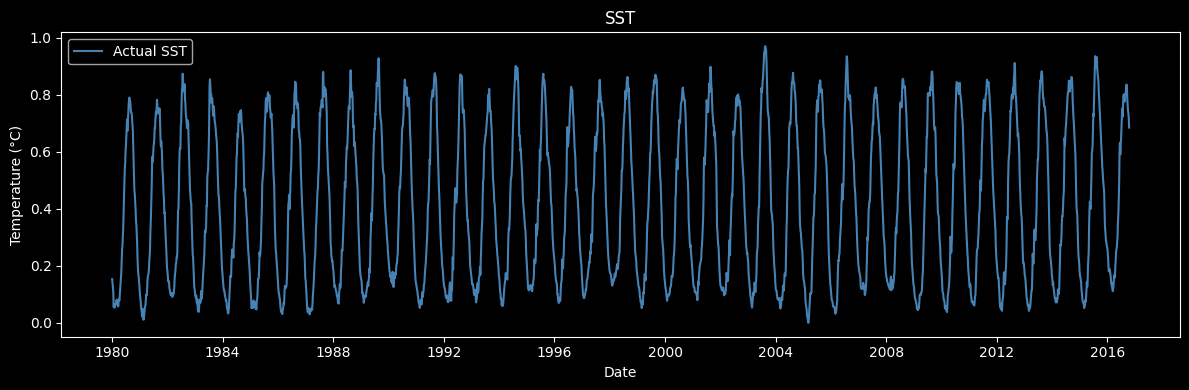

In [37]:

# Construcció de l'eix temporal a partir de les columnes year, month, day
dates = pd.to_datetime(df[['year', 'month', 'day']])

plt.figure(figsize=(12, 4))
plt.plot(dates[:n_train], target_train, label='Actual SST', color='steelblue')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('SST')
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
def create_sequences(features,target, window_size):
    X, y = [], []
    for i in range(window_size, len(features)):
        X.append(features[i-window_size:i])
        y.append(target[i])
    return np.array(X), np.array(y)

WINDOW_SIZE = 12
X_train, y_train = create_sequences(features_train, target_train,  WINDOW_SIZE)
X_test, y_test  = create_sequences(np.concatenate([features_train[-WINDOW_SIZE:], features_test]), np.concatenate([target_train[-WINDOW_SIZE:], target_test]), WINDOW_SIZE)

print(X_train.shape)
print(y_train.shape)

(2637, 12, 4)
(2637, 1)


In [39]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).squeeze()
y_test  = torch.tensor(y_test,  dtype=torch.float32).squeeze()

In [40]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([2637, 12, 4]) torch.Size([2637])
torch.Size([663, 12, 4]) torch.Size([663])


## LSTM

In [41]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x) # difference with RNN
        out = self.fc(out[:, -1, :])  # take the last time step
        return out.squeeze()

In [42]:
model = LSTMModel(input_size=4, hidden_size=64)

criterion = nn.MSELoss() # En aquest cas la funció de pèrdua és de regressió
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 1000
for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.6f}")

Epoch 50/1000 - Loss: 0.060848
Epoch 100/1000 - Loss: 0.032108
Epoch 150/1000 - Loss: 0.007287
Epoch 200/1000 - Loss: 0.003312
Epoch 250/1000 - Loss: 0.002182
Epoch 300/1000 - Loss: 0.001940
Epoch 350/1000 - Loss: 0.001872
Epoch 400/1000 - Loss: 0.001838
Epoch 450/1000 - Loss: 0.001812
Epoch 500/1000 - Loss: 0.001794
Epoch 550/1000 - Loss: 0.001778
Epoch 600/1000 - Loss: 0.001766
Epoch 650/1000 - Loss: 0.001753
Epoch 700/1000 - Loss: 0.001741
Epoch 750/1000 - Loss: 0.001784
Epoch 800/1000 - Loss: 0.001722
Epoch 850/1000 - Loss: 0.001714
Epoch 900/1000 - Loss: 0.001745
Epoch 950/1000 - Loss: 0.001760
Epoch 1000/1000 - Loss: 0.001694


In [43]:
model.eval()
with torch.no_grad():
    predictions = model(X_test)

# Desnormalització
print(predictions.numpy().reshape(-1, 1).shape)
print(y_test.numpy().reshape(-1, 1).shape)
predictions_real = scaler_target.inverse_transform(predictions.numpy().reshape(-1, 1))
y_test_real = scaler_target.inverse_transform(y_test.numpy().reshape(-1, 1))

mae  = mean_absolute_error(y_test_real, predictions_real)
rmse = np.sqrt(np.mean((y_test_real - predictions_real) ** 2))
mape = np.mean(np.abs((y_test_real - predictions_real) / y_test_real)) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


(663, 1)
(663, 1)
MAE:  0.77
RMSE: 0.99
MAPE: 3.76%


## GRU

In [25]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, h_n = self.gru(x)
        out = self.fc(out[:, -1, :])  # take the last time step
        return out.squeeze()

In [26]:
gru_model = GRUModel(input_size=4, hidden_size=64)

criterion = nn.MSELoss() # En aquest cas la funció de pèrdua és de regressió
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)

epochs = 1000
for epoch in range(epochs):
    gru_model.train()
    y_pred = gru_model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.6f}")

Epoch 50/1000 - Loss: 0.057282
Epoch 100/1000 - Loss: 0.049766
Epoch 150/1000 - Loss: 0.040220
Epoch 200/1000 - Loss: 0.026216
Epoch 250/1000 - Loss: 0.012776
Epoch 300/1000 - Loss: 0.003618
Epoch 350/1000 - Loss: 0.002823
Epoch 400/1000 - Loss: 0.002376
Epoch 450/1000 - Loss: 0.002092
Epoch 500/1000 - Loss: 0.001936
Epoch 550/1000 - Loss: 0.001864
Epoch 600/1000 - Loss: 0.001825
Epoch 650/1000 - Loss: 0.001801
Epoch 700/1000 - Loss: 0.001787
Epoch 750/1000 - Loss: 0.001768
Epoch 800/1000 - Loss: 0.001755
Epoch 850/1000 - Loss: 0.001750
Epoch 900/1000 - Loss: 0.001737
Epoch 950/1000 - Loss: 0.002024
Epoch 1000/1000 - Loss: 0.001724


In [30]:
gru_model.eval()
with torch.no_grad():
    predictions_gru = gru_model(X_test)

# Desnormalització
print(predictions_gru.numpy().reshape(-1, 1).shape)
print(y_test.numpy().reshape(-1, 1).shape)
predictions_real_gru = scaler_target.inverse_transform(predictions_gru.numpy().reshape(-1, 1))

mae_gru  = mean_absolute_error(y_test_real, predictions_real_gru)
rmse_gru = np.sqrt(np.mean((y_test_real - predictions_real_gru) ** 2))
mape_gru = np.mean(np.abs((y_test_real - predictions_real_gru) / y_test_real)) * 100

print(f"MAE:  {mae_gru:.2f}")
print(f"RMSE: {rmse_gru:.2f}")
print(f"MAPE: {mape_gru:.2f}%")


(663, 1)
(663, 1)
MAE:  0.74
RMSE: 0.95
MAPE: 3.64%


## Results

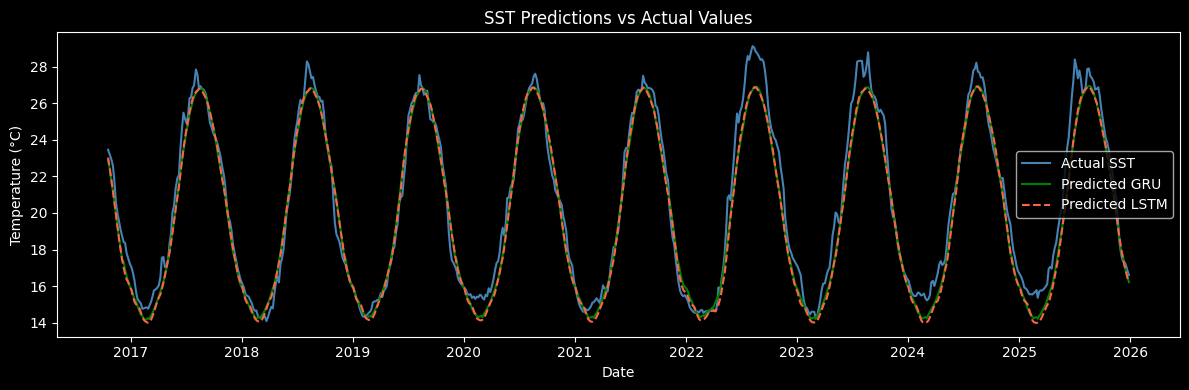

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# Construcció de l'eix temporal a partir de les columnes year, month, day
dates = pd.to_datetime(df[['year', 'month', 'day']])

plt.figure(figsize=(12, 4))
plt.plot(dates[n_train:], y_test_real, label='Actual SST', color='steelblue')
plt.plot(dates[n_train:], predictions_real_gru, label='Predicted GRU', color='green')
plt.plot(dates[n_train:], predictions_real, label='Predicted LSTM', color='tomato', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('SST Predictions vs Actual Values')
plt.legend()
plt.tight_layout()
plt.show()

| Model | MAE  | RMSE | MAPE (%) |
|-------|------|------|----------|
| RNN   | 0.72 | 0.91  | 3.47%    |
| LSTM  | 0.77 | 0.98 | 3.83%    |
| GRU   | 0.74 | 0.95 | 3.64%    |